<a href="https://colab.research.google.com/github/Rudra-CSER/-Healthcare-Risk-Predictor/blob/main/pima_pipeline_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PIMA Diabetes Dataset — EDA
Author: Rudra_CSER | Dataset: UCI PIMA | Goal: Identify key features

## Key Findings

Based on the Exploratory Data Analysis of the PIMA Diabetes Dataset, here are 5 key insights:

1.  **Glucose is the Strongest Predictor:** The `Glucose` feature shows the highest positive correlation with the `Outcome` (diabetes) at **0.47**. Furthermore, diabetic individuals have a significantly higher average glucose level (**141.26**) compared to non-diabetic individuals (**109.98**).
2.  **BMI and Age are Significant Risk Factors:** `BMI` (correlation **0.29**) and `Age` (correlation **0.24**) are also strong indicators of diabetes. Diabetic patients exhibit higher average BMI (**35.14** vs **30.30**) and are generally older (average age **37.07** vs **31.19**).
3.  **Pregnancies Show a Moderate Association:** The number of `Pregnancies` has a correlation of **0.22** with the `Outcome`. Diabetic women in the dataset have a higher average number of pregnancies (**4.87**) compared to non-diabetic women (**3.30**).
4.  **Weakest Predictors Identified:** `BloodPressure` (correlation **0.07**) and `SkinThickness` (correlation **0.07**) have the lowest positive correlation with the `Outcome`, suggesting they are less influential as individual predictors compared to other features.
5.  **Clear Separation in Key Feature Distributions:** Visualizations like box plots (e.g., for `Glucose`, `BMI`, `Age` grouped by `Outcome`) clearly demonstrate distinct distributions, with higher medians and interquartile ranges for diabetic individuals across these key features, reinforcing their predictive power.

## Features Selected for Modelling

Based on the Exploratory Data Analysis, especially the correlation matrix and individual feature distributions, the following features are strong candidates for inclusion in a predictive model for diabetes:

1.  **Glucose:** This feature exhibits the strongest positive correlation with the 'Outcome' (0.47). The clear distinction in average glucose levels between diabetic and non-diabetic individuals makes it a highly influential predictor.
2.  **BMI (Body Mass Index):** With a correlation of 0.29, BMI is another significant risk factor. Diabetic patients generally have a higher average BMI, indicating its importance.
3.  **Age:** Age shows a notable correlation of 0.24. Older individuals tend to have a higher incidence of diabetes, making age a crucial demographic factor.
4.  **Pregnancies:** Correlated at 0.22, the number of pregnancies is a relevant factor, particularly in this dataset which focuses on females. Diabetic women tend to have a higher average number of pregnancies.
5.  **DiabetesPedigreeFunction:** This genetic predisposition score has a correlation of 0.17. While moderate, it provides valuable information about family history and genetic risk.

**Justification for Exclusion (Initial Consideration):**

*   **Insulin (0.13), SkinThickness (0.07), and BloodPressure (0.07):** These features show weaker correlations with the 'Outcome' compared to others. While they might have some predictive power, their individual impact is less significant. For an initial model, focusing on the stronger predictors can lead to a more robust and interpretable model. Further analysis might explore their contribution in combination with other features.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as np
df = np.read_csv('/content/drive/MyDrive/Raw CSV/diabetes.csv')

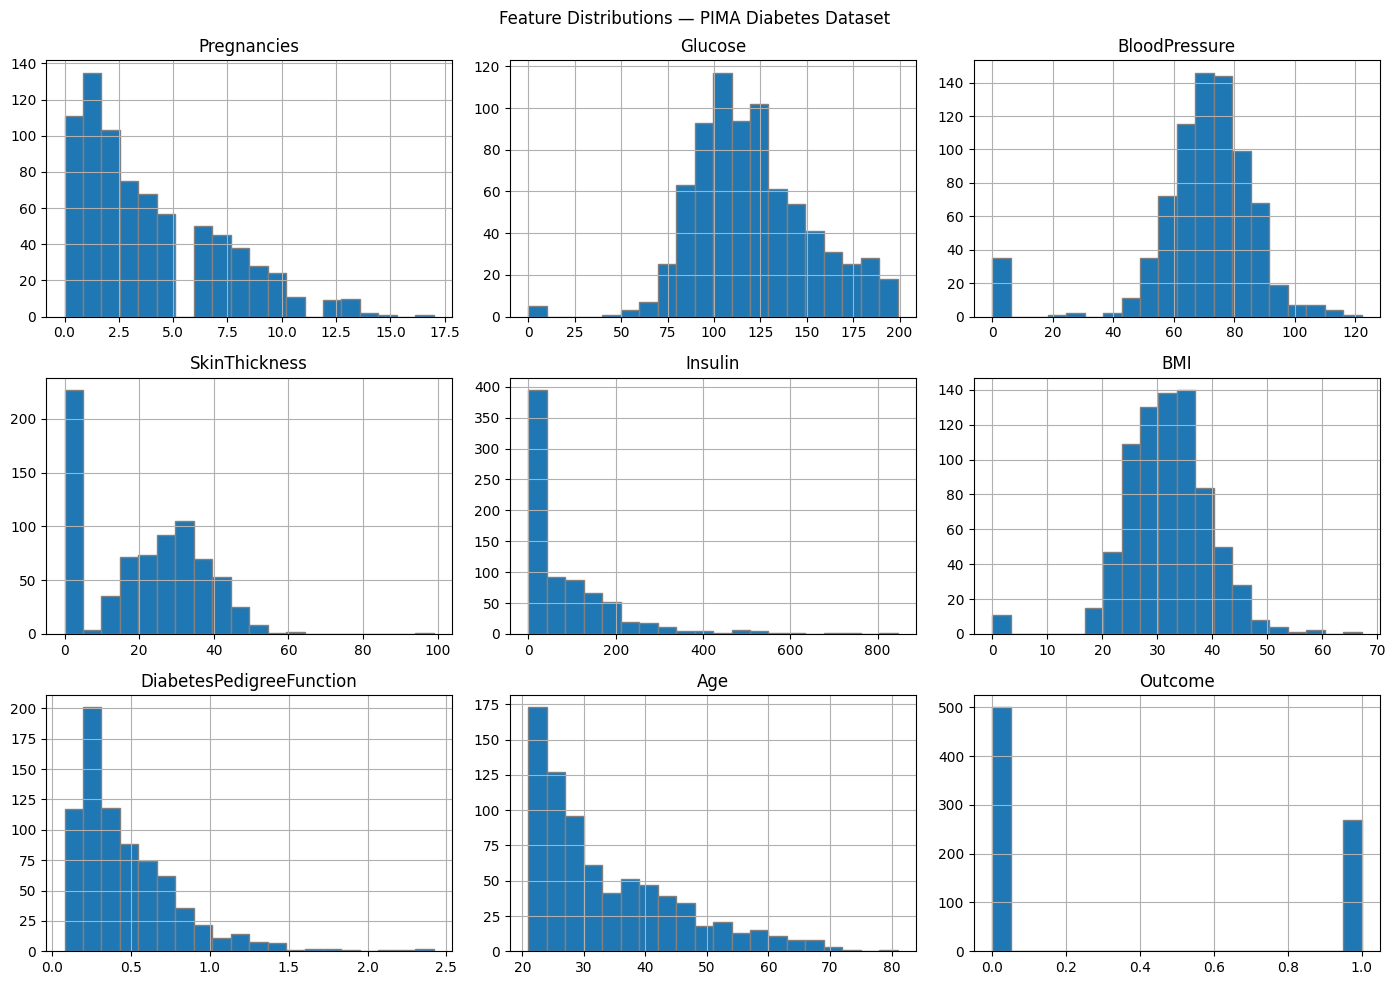

In [6]:
import matplotlib.pyplot as plt
df.hist(figsize=(14,10),bins=20 , edgecolor='grey')
plt.suptitle('Feature Distributions — PIMA Diabetes Dataset')
plt.tight_layout()
plt.show()

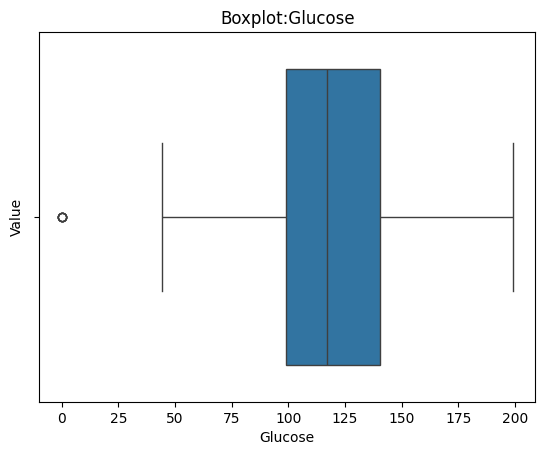

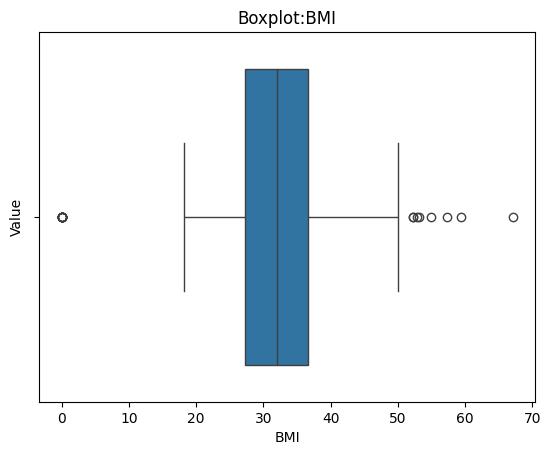

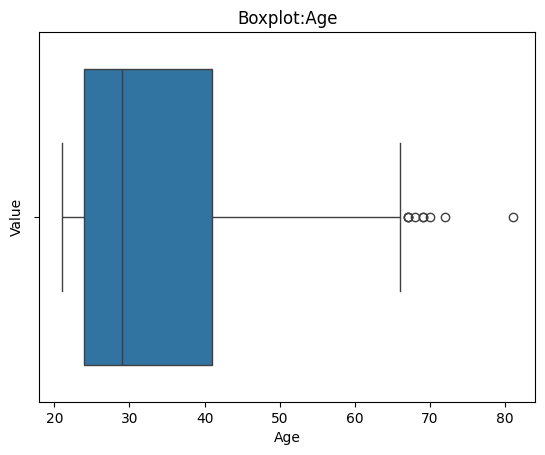

In [7]:
import seaborn as sns
for col in ['Glucose', 'BMI','Age']:
 plt.figure()
 sns.boxplot(x=df[col])
 plt.title(f'Boxplot:{col}')
 plt.xlabel(col) # Added explicit x-axis label
 plt.ylabel('Value') # Added explicit y-axis label
 plt.show()

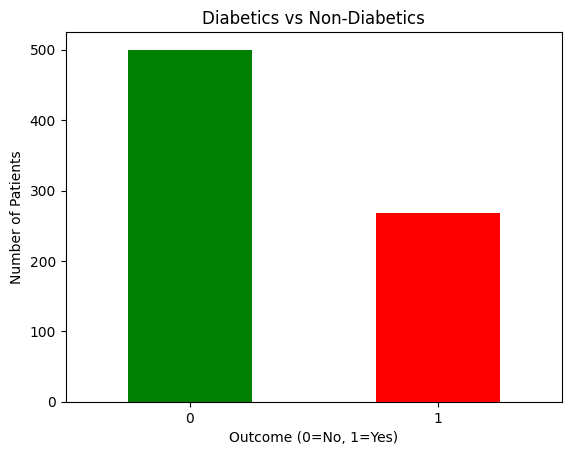

In [8]:
df['Outcome'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Diabetics vs Non-Diabetics')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

In [9]:
comparison = df.groupby('Outcome').mean().T
comparison.coloums = ['Diabetic (1)', 'Non-Diabetic (0)']
print(comparison)

Outcome                            0           1
Pregnancies                 3.298000    4.865672
Glucose                   109.980000  141.257463
BloodPressure              68.184000   70.824627
SkinThickness              19.664000   22.164179
Insulin                    68.792000  100.335821
BMI                        30.304200   35.142537
DiabetesPedigreeFunction    0.429734    0.550500
Age                        31.190000   37.067164


/tmp/ipykernel_1143/4106679653.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  comparison.coloums = ['Diabetic (1)', 'Non-Diabetic (0)']


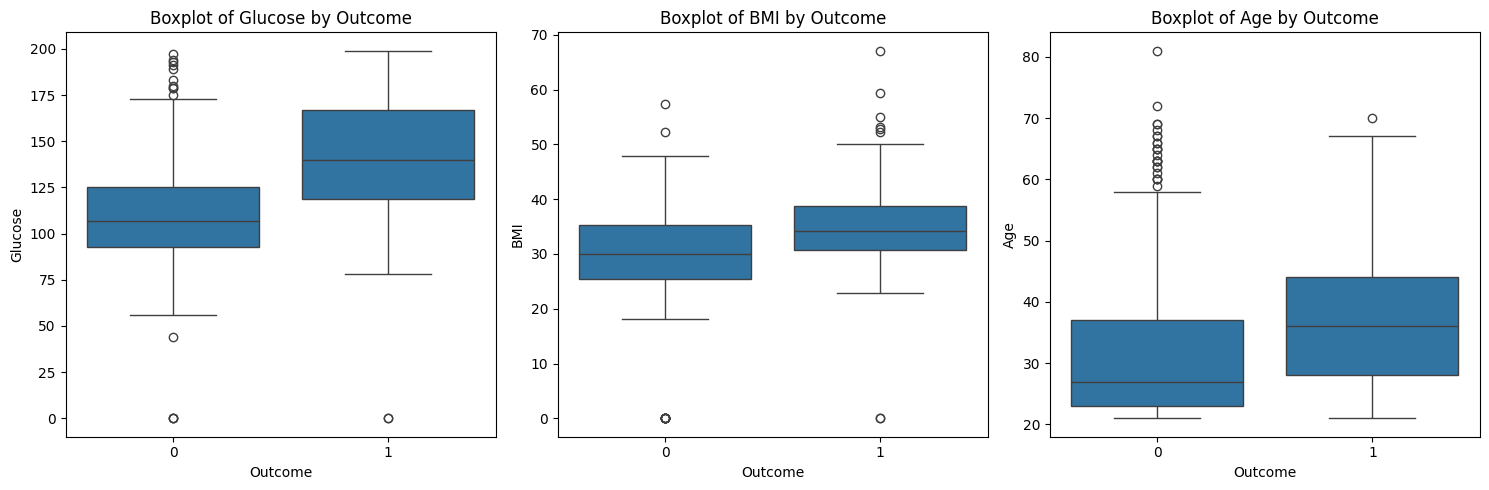

In [10]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
for ax,col in zip(axes, ['Glucose' ,'BMI' , 'Age']):
 sns.boxplot(x='Outcome', y=col, data=df, ax=ax )
 ax.set_title(f'Boxplot of {col} by Outcome')
plt.tight_layout()
plt.show()

Side-by-side box plot using sns bloxspot mainly targeted for specific columns box plotting.

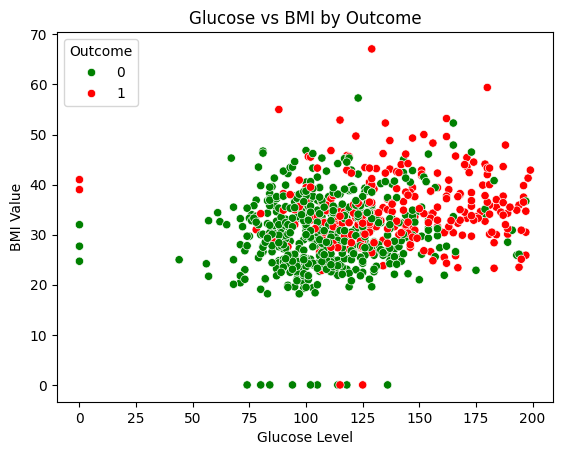

In [11]:
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette={0:'green', 1:'red'})
plt.title('Glucose vs BMI by Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('BMI Value')
plt.show()

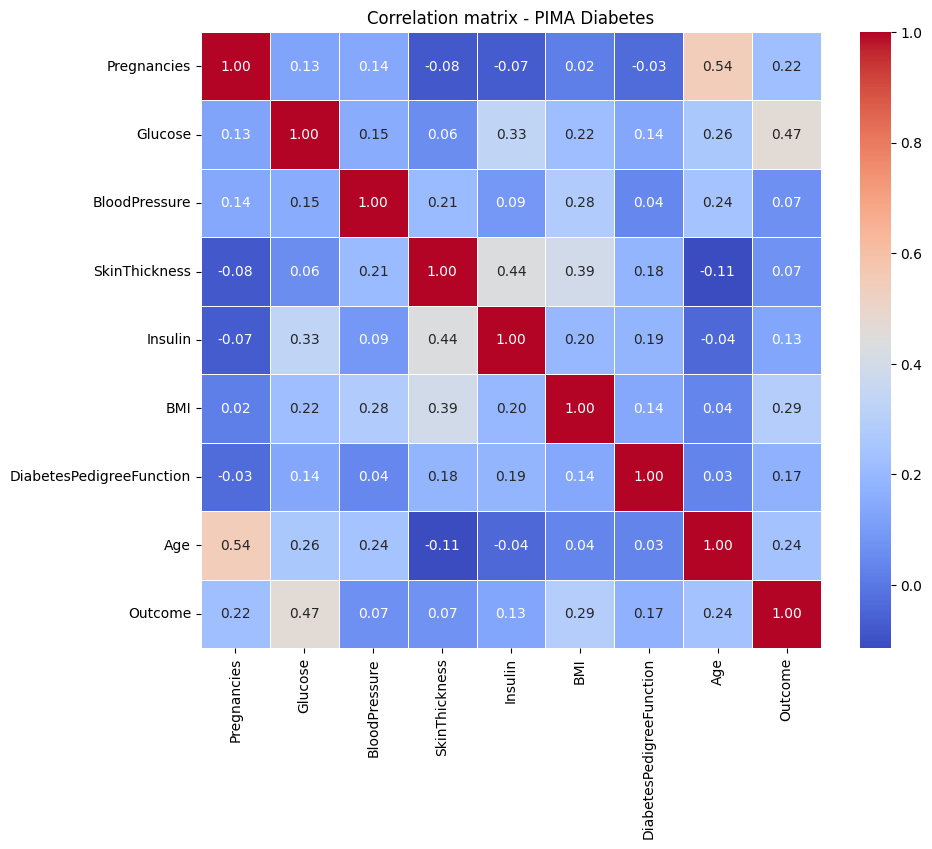

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation matrix - PIMA Diabetes')
plt.show()

In [13]:
corr = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr)

Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


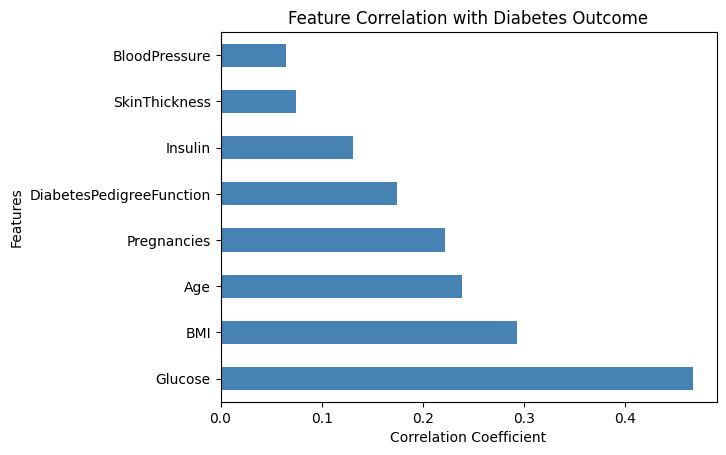

In [14]:
corr.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Diabetes Outcome')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()